# A/B TESTING
## PROJECT OBJECTIVE
Finding out if brand familiarity will accelerate purchase decisions? Users who had prior exposure to a brand (viewed/carted before) vs. first-time brand encounters — do they convert in fewer sessions and at a higher rate?


In [1]:
import pandas as pd
import numpy as np

In [2]:
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings("ignore")

## LOAD IN AND INTITAL INSPECTION

In [3]:
df = pd.read_csv("2019-Oct.csv")

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [5]:
# Parse timestamps
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)

In [6]:
print(f"Rows loaded      : {len(df):,}")
print(f"Date range       : {df['event_time'].min()} → {df['event_time'].max()}")
print(f"Unique users     : {df['user_id'].nunique():,}")
print(f"Unique brands    : {df['brand'].nunique():,}")
print(f"\nEvent type breakdown:")
print(df["event_type"].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())

Rows loaded      : 42,448,764
Date range       : 2019-10-01 00:00:00+00:00 → 2019-10-31 23:59:59+00:00
Unique users     : 3,022,290
Unique brands    : 3,444

Event type breakdown:
event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

Missing values:
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64


# DATA CLEANING

In [7]:
# Keep only what the analysis needs
df_clean = df[["event_time", "event_type", "brand", "price", "user_id", "user_session"]].copy()
# Drop rows with no brand (can't test brand familiarity without it)
df_clean = df_clean.dropna(subset=["brand"])
df_clean["brand"] = df_clean["brand"].str.lower().str.strip()

In [8]:
# Keep only relevant event types (remove 'remove_from_cart' if present)
df_clean = df_clean[df_clean["event_type"].isin(["view", "cart", "purchase"])]

In [9]:
# Sort chronologically — critical for correctly labeling "prior" exposure
df_clean = df_clean.sort_values(["user_id", "brand", "event_time"]).reset_index(drop=True)

In [10]:
df_clean = df_clean.dropna(subset=["user_session"])

In [11]:
print(f"\nMissing values:")
print(df_clean.isnull().sum())


Missing values:
event_time      0
event_type      0
brand           0
price           0
user_id         0
user_session    0
dtype: int64


In [12]:
print(f"Rows after cleaning : {len(df_clean):,}")
print(f"Brands retained     : {df_clean['brand'].nunique():,}")

Rows after cleaning : 36,331,682
Brands retained     : 3,444


# BUILD USER-BRAND ENCOUNTER TABLE

In [15]:
# For each (user, brand) pair, find:
#   - total sessions where they encountered the brand
#   - whether they ever purchased
#   - how many sessions before first purchase
 
def build_encounter_table(df):
    records = []
 
    grouped = df_clean.groupby(["user_id", "brand"])
 
    for (user_id, brand), group in grouped:
        group = group.sort_values("event_time")
 
        sessions = group["user_session"].unique()
        n_sessions = len(sessions)
 
        purchased = (group["event_type"] == "purchase").any()
 
        # Sessions to first purchase (None if never purchased)
        if purchased:
            first_purchase_session_idx = None
            for i, session in enumerate(sessions):
                session_events = group[group["user_session"] == session]["event_type"]
                if "purchase" in session_events.values:
                    first_purchase_session_idx = i + 1  # 1-indexed
                    break
        else:
            first_purchase_session_idx = None
 
        # Prior brand exposure flag:
        # Does this user have any view or cart event for this brand
        # BEFORE their first session with this brand?
        # We define "returning" as: user had 2+ sessions with this brand
        # (first session = control, any subsequent session = treatment)
        is_returning = n_sessions > 1
 
        records.append({
            "user_id": user_id,
            "brand": brand,
            "n_sessions": n_sessions,
            "purchased": int(purchased),
            "sessions_to_purchase": first_purchase_session_idx,
            "group": "treatment" if is_returning else "control"
        })
 
    return pd.DataFrame(records)

In [16]:
encounters = build_encounter_table(df_clean)

In [18]:
print(f"Total user-brand pairs  : {len(encounters):,}")
print(f"\nGroup breakdown:")
print(encounters["group"].value_counts())
print(f"\nOverall purchase rate   : {encounters['purchased'].mean():.2%}")

Total user-brand pairs  : 10,176,157

Group breakdown:
group
control      8021327
treatment    2154830
Name: count, dtype: int64

Overall purchase rate   : 4.17%


Above shows basically an 80/20 split, showing that 80 million encounter the brand once and does not come back. The other 2.1 million keep going back to the brand.

## POWER ANALYSIS
Do I have enough data?

In [23]:
# Estimate baseline conversion from control group
control_rate = encounters[encounters["group"] == "control"]["purchased"].mean()
# Minimum detectable effect: 2 percentage points
# The minimum detectable effect is the smallest change in a metric that an experiment can reliably identify as statistically significant
# Which basiclaly means the smallest change worht caring about
# MDE is typically between 2 and 5%
mde = 0.02
# Setting the MDE to 2% means that we only care if returning visitors convert at least 2 percentage points higher than first-timers
treatment_rate_expected = control_rate + mde
 
effect_size = proportion_effectsize(control_rate, treatment_rate_expected)
analysis = NormalIndPower() # calculating the statistical power or sample size of a 2-smaple test
required_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05, # false positive tolerance
    power=0.80, # false negative tolerance
    ratio=1.0 # ratio of control to treatment 
)

In [24]:
actual_n_control = (encounters["group"] == "control").sum()
actual_n_treatment = (encounters["group"] == "treatment").sum()

In [25]:
print(f"Baseline conversion rate (control) : {control_rate:.2%}")
print(f"Minimum detectable effect (MDE)    : {mde:.2%}")
print(f"Required sample size (per group)   : {required_n:,.0f}")
print(f"Actual control group size          : {actual_n_control:,}")
print(f"Actual treatment group size        : {actual_n_treatment:,}")
print(f"Adequately powered                 : {'YES' if min(actual_n_control, actual_n_treatment) >= required_n else 'NO'}")

Baseline conversion rate (control) : 1.83%
Minimum detectable effect (MDE)    : 2.00%
Required sample size (per group)   : 1,044
Actual control group size          : 8,021,327
Actual treatment group size        : 2,154,830
Adequately powered                 : YES


Above we see that we have plenty of data, seeing that we have so much data though this may be a problem. The required sample size that we would need is 1,044, we have so much more data than that. If this is a problem it will come up later in the analysis.

## SANITY CHECKS

In [26]:
# to check if the split is reasonable
total = len(encounters)
control_pct = actual_n_control / total
treatment_pct = actual_n_treatment / total
print(f"Control   : {actual_n_control:,} ({control_pct:.1%})")
print(f"Treatment : {actual_n_treatment:,} ({treatment_pct:.1%})")
print("Note: Unequal split expected — observational study, not random assignment.")

Control   : 8,021,327 (78.8%)
Treatment : 2,154,830 (21.2%)
Note: Unequal split expected — observational study, not random assignment.


In [27]:
# Verify no user appears in both groups (they shouldn't — group is per user-brand pair,
# but a user CAN appear in both groups for different brands, which is fine)
print(f"\nUsers appearing in both groups (different brands): expected & OK")
both = encounters.groupby("user_id")["group"].nunique()
print(f"  Users in only control   : {(both == 1).sum():,} (these only ever had 1 session per brand)")
print(f"  Users spanning both groups : {(both == 2).sum():,} (had 1-session and multi-session brands)")


Users appearing in both groups (different brands): expected & OK
  Users in only control   : 2,074,958 (these only ever had 1 session per brand)
  Users spanning both groups : 785,878 (had 1-session and multi-session brands)


Because group assignment is at the user-brand level rather than the user level, some users appear in both groups across different brands. This is expected given the observational nature of the study.

## PRIMARY ANALYSIS
Z-test

In [28]:
control = encounters[encounters["group"] == "control"]
treatment = encounters[encounters["group"] == "treatment"]

In [29]:
control_conversions = control["purchased"].sum()
treatment_conversions = treatment["purchased"].sum()
control_n = len(control)
treatment_n = len(treatment)

In [30]:
control_rate = control_conversions / control_n
treatment_rate = treatment_conversions / treatment_n
lift = (treatment_rate - control_rate) / control_rate # creates a more intuitve number

In [31]:
# Two-proportion z-test (one-sided: treatment > control)
count = np.array([treatment_conversions, control_conversions])
nobs = np.array([treatment_n, control_n])
z_stat, p_value = proportions_ztest(count, nobs, alternative="larger")

In [32]:
# 95% Confidence interval on the difference
se = np.sqrt(
    (control_rate * (1 - control_rate) / control_n) +
    (treatment_rate * (1 - treatment_rate) / treatment_n)
)
diff = treatment_rate - control_rate
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

In [34]:
print(f"Control conversion rate   : {control_rate:.4%}  (n={control_n:,})")
print(f"Treatment conversion rate : {treatment_rate:.4%}  (n={treatment_n:,})")
print(f"Absolute lift             : {diff:.4%}")
print(f"Relative lift             : {lift:.2%}")
print(f"95% CI on difference      : [{ci_lower:.4%}, {ci_upper:.4%}]")
print(f"Z-statistic               : {z_stat:.4f}")
print(f"P-value (one-sided)       : {p_value:.6f}")
print(f"\nResult: {'STATISTICALLY SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (α=0.05)")

Control conversion rate   : 1.8267%  (n=8,021,327)
Treatment conversion rate : 12.9141%  (n=2,154,830)
Absolute lift             : 11.0874%
Relative lift             : 606.98%
95% CI on difference      : [11.0417%, 11.1332%]
Z-statistic               : 722.4851
P-value (one-sided)       : 0.000000

Result: STATISTICALLY SIGNIFICANT (α=0.05)


Important note aout the above: The magnitude of lift (606%) suggests selection bias in group assignment — returning visitors likely represent higher-intent shoppers rather than users causally influenced by brand exposure. A true causal test would require randomized assignment, such as experimentally varying brand reminder touchpoints.

## SECONDARY ANALYSIS
Mann-Whitney U

In [35]:
# Only look at users who actually purchased
control_converted = control[control["purchased"] == 1]["sessions_to_purchase"].dropna()
treatment_converted = treatment[treatment["purchased"] == 1]["sessions_to_purchase"].dropna()

In [36]:
print(f"Control   — median sessions to purchase : {control_converted.median():.1f}  (n={len(control_converted):,})")
print(f"Treatment — median sessions to purchase : {treatment_converted.median():.1f}  (n={len(treatment_converted):,})")

Control   — median sessions to purchase : 1.0  (n=146,522)
Treatment — median sessions to purchase : 2.0  (n=278,277)


In [37]:
# Mann-Whitney U (non-parametric — sessions data is skewed, not normal)
u_stat, p_mw = mannwhitneyu(control_converted, treatment_converted, alternative="greater")
print(f"\nMann-Whitney U statistic : {u_stat:.0f}")
print(f"P-value (one-sided)      : {p_mw:.6f}")
print(f"Result: {'STATISTICALLY SIGNIFICANT' if p_mw < 0.05 else 'NOT SIGNIFICANT'} (α=0.05)")
 


Mann-Whitney U statistic : 7347931778
P-value (one-sided)      : 1.000000
Result: NOT SIGNIFICANT (α=0.05)


The p-value being one makes perfect since, it means the the result went in the opposite direction of the hypothesis. The hypothesis was that returning visitors would purchase in fewer sessions, but they actually take more sessions. This makes sense because they had more sessions by definition.
The primary and secondary analysis together show that people who make a visit to a brand more before making a purchase, they are more intent on their purchases. 

## VISUALIZATIONS

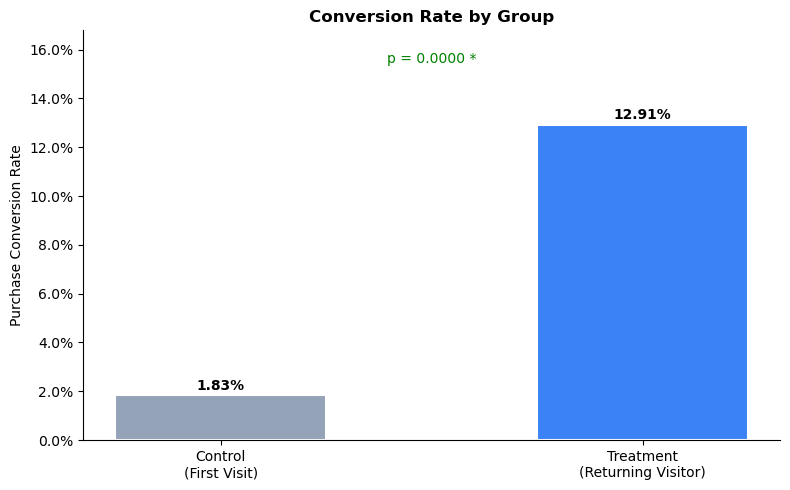

In [42]:
palette = {"control": "#94a3b8", "treatment": "#3b82f6"}

fig, ax = plt.subplots(figsize=(8, 5))
rates = pd.DataFrame({
    "Group": ["Control\n(First Visit)", "Treatment\n(Returning Visitor)"],
    "Conversion Rate": [control_rate, treatment_rate],
    "color": [palette["control"], palette["treatment"]]
})
bars = ax.bar(rates["Group"], rates["Conversion Rate"], color=rates["color"], width=0.5, edgecolor="white", linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_title("Conversion Rate by Group", fontweight="bold")
ax.set_ylabel("Purchase Conversion Rate")
for bar, val in zip(bars, rates["Conversion Rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{val:.2%}", ha="center", va="bottom", fontweight="bold")
sig_text = f"p = {p_value:.4f} {'*' if p_value < 0.05 else 'ns'}"
ax.text(0.5, 0.92, sig_text, transform=ax.transAxes, ha="center",
        fontsize=10, color="green" if p_value < 0.05 else "gray")
ax.set_ylim(0, max(control_rate, treatment_rate) * 1.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

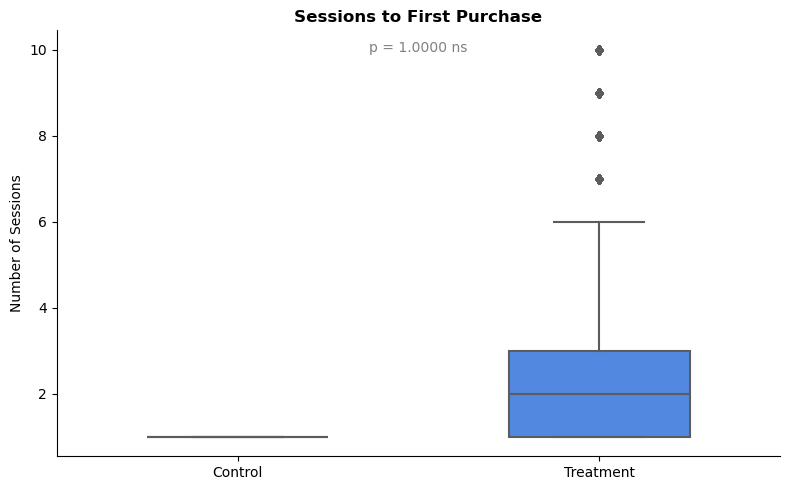

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = pd.concat([
    control_converted.rename("sessions").to_frame().assign(group="Control"),
    treatment_converted.rename("sessions").to_frame().assign(group="Treatment")
])
plot_data = plot_data[plot_data["sessions"] <= 10]
sns.boxplot(data=plot_data, x="group", y="sessions", 
            palette={"Control": "#94a3b8", "Treatment": "#3b82f6"},  # fixed here
            ax=ax, order=["Control", "Treatment"], width=0.5)
ax.set_title("Sessions to First Purchase", fontweight="bold")
ax.set_ylabel("Number of Sessions")
ax.set_xlabel("")
ax.spines[["top", "right"]].set_visible(False)
sig_text2 = f"p = {p_mw:.4f} {'*' if p_mw < 0.05 else 'ns'}"
ax.text(0.5, 0.95, sig_text2, transform=ax.transAxes, ha="center",
        fontsize=10, color="green" if p_mw < 0.05 else "gray")
plt.tight_layout()
plt.show()

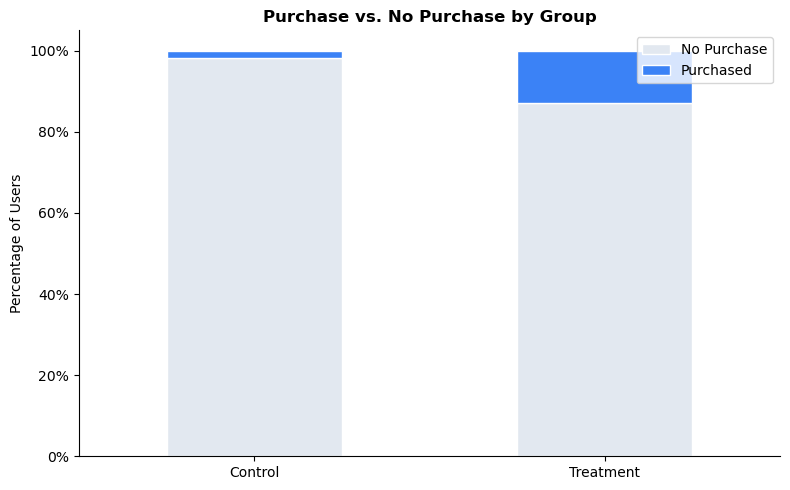

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
funnel_data = encounters.groupby("group").agg(
    total=("user_id", "count"),
    purchased=("purchased", "sum")
).reset_index()
funnel_data["not_purchased"] = funnel_data["total"] - funnel_data["purchased"]
funnel_pct = funnel_data.set_index("group")[["not_purchased", "purchased"]]
funnel_pct_norm = funnel_pct.div(funnel_pct.sum(axis=1), axis=0) * 100
funnel_pct_norm.plot(kind="bar", stacked=True, ax=ax,
                     color=["#e2e8f0", "#3b82f6"], edgecolor="white")
ax.set_title("Purchase vs. No Purchase by Group", fontweight="bold")
ax.set_ylabel("Percentage of Users")
ax.set_xlabel("")
ax.set_xticklabels(["Control", "Treatment"], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(["No Purchase", "Purchased"], loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## BUSINESS IMPACT SUMMARY

In [48]:
print(f"""
EXPERIMENT SUMMARY
------------------
Question   : Does prior brand exposure increase purchase conversion?
Control    : First-time brand encounter       ({control_n:,} users)
Treatment  : Returning brand visitor          ({treatment_n:,} users)
 
PRIMARY METRIC (Conversion Rate)
  Control   : {control_rate:.3%}
  Treatment : {treatment_rate:.3%}
  Lift      : +{diff:.3%} absolute  ({lift:.1%} relative)
  95% CI    : [{ci_lower:.3%}, {ci_upper:.3%}]
  p-value   : {p_value:.4f}  →  {'Significant ✓' if p_value < 0.05 else 'Not Significant ✗'}
 
SECONDARY METRIC (Sessions to Purchase)
  Control median   : {control_converted.median():.1f} sessions
  Treatment median : {treatment_converted.median():.1f} sessions
  p-value (MW-U)   : {p_mw:.4f}  →  {'Significant ✓' if p_mw < 0.05 else 'Not Significant ✗'}
 
REAL WORLD ANALOGY
  In a real estate context, this mirrors users who save or revisit
  listings converting at a much higher rate than cold visitors, though
  requiring more touchpoints before committing. Suggests that
  re-engagement campaigns (saved homes, price drop alerts) should
  focus on nurturing high-intent users over time rather than
  pushing for immediate conversion.
""")


EXPERIMENT SUMMARY
------------------
Question   : Does prior brand exposure increase purchase conversion?
Control    : First-time brand encounter       (8,021,327 users)
Treatment  : Returning brand visitor          (2,154,830 users)
 
PRIMARY METRIC (Conversion Rate)
  Control   : 1.827%
  Treatment : 12.914%
  Lift      : +11.087% absolute  (607.0% relative)
  95% CI    : [11.042%, 11.133%]
  p-value   : 0.0000  →  Significant ✓
 
SECONDARY METRIC (Sessions to Purchase)
  Control median   : 1.0 sessions
  Treatment median : 2.0 sessions
  p-value (MW-U)   : 1.0000  →  Not Significant ✗
 
REAL WORLD ANALOGY
  In a real estate context, this mirrors users who save or revisit
  listings converting at a much higher rate than cold visitors, though
  requiring more touchpoints before committing. Suggests that
  re-engagement campaigns (saved homes, price drop alerts) should
  focus on nurturing high-intent users over time rather than
  pushing for immediate conversion.

